In [36]:
#import lib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn import metrics
import pandas as pd


In [37]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:

import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/ML/Dataset/diabetes.csv')

In [39]:
type(data)

pandas.core.frame.DataFrame

In [40]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [41]:
data.shape

(768, 9)

In [42]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [43]:
data.duplicated().sum()

np.int64(0)

In [44]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


<Axes: xlabel='Outcome'>

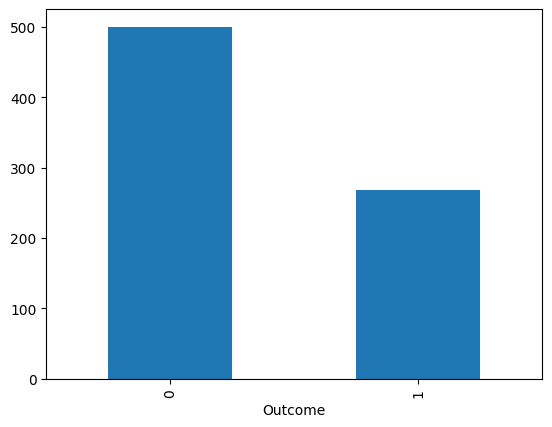

In [45]:
data['Outcome'].value_counts().plot.bar()

In [46]:
X = data.iloc[:,:-1]

In [47]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [48]:
Y = data.iloc[:,-1]

In [49]:
X.ndim

2

In [50]:
Y.ndim

1

In [51]:
Y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [52]:
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.2,random_state=42)

In [53]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26
106,1,96,122,0,0,22.4,0.207,27
270,10,101,86,37,0,45.6,1.136,38
435,0,141,0,0,0,42.4,0.205,29


In [54]:
sc = MinMaxScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [55]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26
106,1,96,122,0,0,22.4,0.207,27
270,10,101,86,37,0,45.6,1.136,38
435,0,141,0,0,0,42.4,0.205,29


In [56]:
logreg = LogisticRegression()
logreg.fit(x_train_sc,y_train)

LogisticRegression()

In [57]:
y_pred = logreg.predict(x_test_sc)

In [58]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [59]:
com = {"Actual y" : y_test, "Predict y" : y_pred}

In [60]:
com_df = pd.DataFrame(com)

In [61]:
com_df

,Actual y,Predict y
668,0,0
324,0,0
624,0,0
690,0,0
473,0,0
...,...,...
355,1,1
534,0,0
344,0,0
296,1,0


In [62]:
log_acc = metrics.accuracy_score(y_test,y_pred)
print(log_acc)

0.7532467532467533


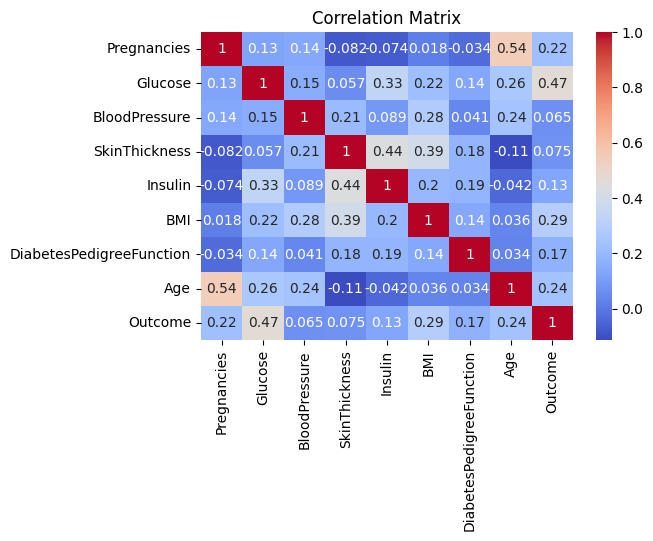

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Prediction
y_pred = logreg.predict(x_test_sc)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1-score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
y_prob = logreg.predict_proba(x_test_sc)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print(f"ROC-AUC: {roc_auc*100:.2f}%")

Precision: 68.09%
Recall: 58.18%
F1-Score: 62.75%
ROC-AUC: 81.29%


In [65]:
score = logreg.score(x_test_sc, y_test)
print("\nModel Performance: ", round(score * 100, 2),"%")


Model Performance:  75.32 %


In [66]:
import numpy as np
import pandas as pd

# Take user input
user_input = input(
    "Enter values for 8 features (comma-separated):\n"
    "Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, "
    "DiabetesPedigreeFunction, Age:\n"
)

# Convert input to NumPy array
user_values = np.array(
    [float(x.strip()) for x in user_input.split(",")]
).reshape(1, -1)

# Get feature names from the training data (x_train)
feature_names = x_train.columns

# Convert user_values to a DataFrame with feature names
user_values_df = pd.DataFrame(user_values, columns=feature_names)

# Scale user input using the SAME scaler
user_values_sc = sc.transform(user_values_df)
# Predict
user_pred = logreg.predict(user_values_sc)
# Probability
prob = logreg.predict_proba(user_values_sc)[0][1]

# Show result
if user_pred[0] == 1:
    print(f"🔴 Prediction: You have diabetes (Probability: {prob:.2f})")
else:
    print(f"🟢 Prediction: You do NOT have diabetes (Probability: {prob:.2f})")

Enter values for 8 features (comma-separated):
Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age:
2, 197, 70, 45,	543,	30.5, 0.158, 53	
🔴 Prediction: You have diabetes (Probability: 0.75)


***STREAMLINE***

In [67]:
import pickle

# Save trained model
with open("model.pkl", "wb") as file:
    pickle.dump(logreg, file)

# Save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(sc, file)